## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [1]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
from src.data.utils.eda_utils import directory_to_dataframe
from src.data.utils.filter_dataset import filter_dataset


# Собираем пути до картинок в датафрейм
# Дальше будем итерироваться по датафрейму, извлекать признаки картинок, а потом мэтчить картинки на основе этих фичей
path_to_dataset = Path("../../data/01_raw/sneakers-dataset")
df = directory_to_dataframe(path_to_dataset)
# Вычищаем Yeezy Slide, т.к. они не укладываются в наши представления о кроссовках
df = filter_dataset(
    df,
    path_to_dataset,
    class_names_to_remove=['yeezy_slide'],
    bad_images_md_path='../2-exploration/bad_images.md' #Картинки, которые мы признали негодными на этапе EDA
)

df.head()

Отбросили изображений: 12
Осталось изображений: 5796


,path,sneaker_class
0,reebok_classic_leather/0071.jpg,reebok_classic_leather
1,reebok_classic_leather/0065.jpg,reebok_classic_leather
2,reebok_classic_leather/0059.jpg,reebok_classic_leather
3,reebok_classic_leather/0058.jpg,reebok_classic_leather
4,reebok_classic_leather/0064.jpg,reebok_classic_leather


In [4]:
train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

In [5]:
import cv2 as cv

img_path = 'reebok_classic_leather/0004.jpg'
img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

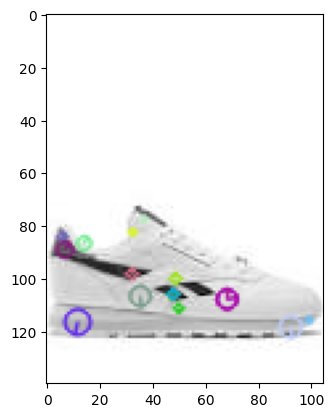

In [6]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [7]:
feature_df = []
for img_path in train['path']:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,0.0,6.0,26.0,24.0,15.0,57.0,26.0,0.0,0.0,5.0,...,35.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
1,9.0,5.0,104.0,93.0,0.0,1.0,7.0,4.0,141.0,45.0,...,0.0,81.0,141.0,57.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
2,101.0,67.0,2.0,1.0,10.0,2.0,0.0,0.0,95.0,39.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_max_90/0055.jpg
3,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,41.0,137.0,1.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
4,0.0,0.0,0.0,4.0,79.0,127.0,17.0,0.0,2.0,0.0,...,11.0,0.0,4.0,49.0,20.0,0.0,0.0,51.0,22.0,nike_air_max_90/0055.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,6.0,3.0,0.0,1.0,3.0,11.0,17.0,6.0,26.0,5.0,...,8.0,93.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,converse_one_star/0024.jpg
28,66.0,10.0,0.0,0.0,150.0,72.0,0.0,1.0,150.0,19.0,...,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,converse_one_star/0024.jpg
29,10.0,8.0,1.0,3.0,20.0,5.0,2.0,4.0,73.0,45.0,...,7.0,132.0,62.0,4.0,0.0,0.0,0.0,0.0,10.0,converse_one_star/0024.jpg
30,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,...,123.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,converse_one_star/0024.jpg


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 200
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneake

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.274s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.084210


/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-

[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.251083
[t-SNE] KL divergence after 1000 iterations: 2.630974


/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_79532/2451772772.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_79532/2451772772.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])


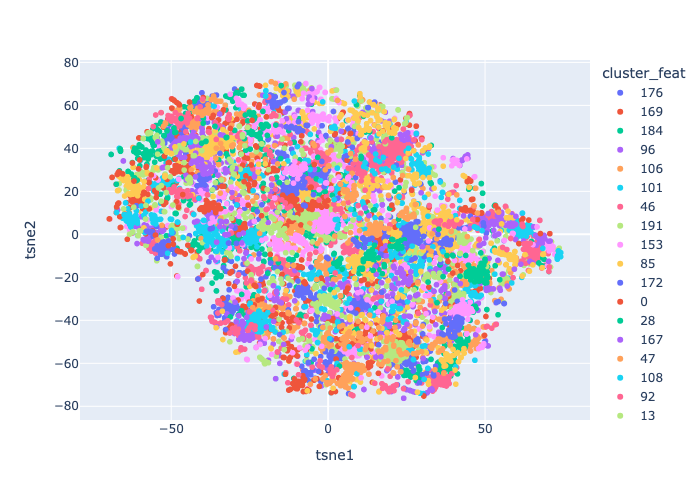

In [9]:
from sklearn.manifold import TSNE
import plotly.express as px
from IPython.display import Image, display


# Assume X is your high-dimensional data matrix and y are labels or target classes
tsne = TSNE(n_components=2, random_state=123, verbose=1)
sample_df = feature_df.sample(10000, random_state=0)
sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
fig = px.scatter(sample_df, x='tsne1', y='tsne2', color='cluster_feat')
display(Image(fig.to_image('png')))

In [10]:
train.set_index('path', inplace=True)


In [11]:
test.set_index('path', inplace=True)

In [12]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,68.0,76.0,4.0,1.0,7.0,22.0,5.0,1.0,167.0,145.0,...,29.0,0.0,0.0,0.0,0.0,2.0,23.0,3.0,0.0,new_balance_574/0039.jpg
1,10.0,2.0,1.0,22.0,79.0,21.0,1.0,1.0,154.0,7.0,...,19.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,0.0,new_balance_574/0039.jpg
2,10.0,48.0,7.0,4.0,13.0,16.0,0.0,0.0,133.0,76.0,...,100.0,10.0,0.0,0.0,0.0,0.0,7.0,10.0,8.0,new_balance_574/0039.jpg
3,62.0,156.0,2.0,0.0,3.0,21.0,10.0,7.0,62.0,156.0,...,34.0,1.0,1.0,0.0,0.0,0.0,36.0,31.0,1.0,new_balance_574/0039.jpg
4,6.0,1.0,0.0,2.0,5.0,10.0,8.0,5.0,126.0,1.0,...,19.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,new_balance_574/0039.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,33.0,45.0,16.0,6.0,6.0,3.0,0.0,3.0,24.0,34.0,...,4.0,0.0,1.0,100.0,88.0,0.0,0.0,2.0,1.0,nike_air_max_90/0121.jpg
336,23.0,0.0,2.0,3.0,2.0,3.0,109.0,129.0,5.0,6.0,...,1.0,38.0,30.0,12.0,5.0,1.0,0.0,2.0,35.0,nike_air_max_90/0121.jpg
337,4.0,14.0,9.0,1.0,0.0,0.0,0.0,0.0,16.0,5.0,...,49.0,22.0,69.0,45.0,12.0,45.0,29.0,13.0,13.0,nike_air_max_90/0121.jpg
338,0.0,0.0,17.0,18.0,12.0,16.0,1.0,0.0,55.0,53.0,...,58.0,5.0,0.0,0.0,0.0,16.0,127.0,127.0,60.0,nike_air_max_90/0121.jpg


In [13]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/89987943.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [14]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conca

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,0,0,0,1,1,0,0,1,1,...,0,1,0,0,0,0,2,2,0,1
nike_cortez/0092.jpg,nike_cortez,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,2
converse_one_star/0005.jpg,converse_one_star,0,2,1,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,0,0,1,1,0,0,0,0,0,...,0,0,1,1,0,0,1,0,0,0
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,2,2,0,0,0,1,0,0,1,...,0,0,1,0,1,0,1,0,1,0
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [15]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,0.000000,0.000000,0.000000,0.081117,0.087934,0.000000,0.0,0.077024,0.092977,...,0.000000,0.073477,0.000000,0.000000,0.000000,0.000000,0.173883,0.155554,0.000000,0.080345
nike_cortez/0092.jpg,nike_cortez,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.172787,0.000000,...,0.000000,0.164830,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,0.110643,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.085780,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.119576,0.187595
converse_one_star/0005.jpg,converse_one_star,0.000000,0.135105,0.049502,0.060205,0.000000,0.000000,0.0,0.057168,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.062891,0.000000,0.000000,0.000000,0.000000
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.108867,0.210706,0.000000,0.000000,0.000000,0.000000,0.090564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,0.000000,0.000000,0.039335,0.047840,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.056338,0.056961,0.000000,0.000000,0.051275,0.000000,0.000000,0.000000
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,0.117597,0.112934,0.000000,0.000000,0.000000,0.060595,0.0,0.000000,0.057684,...,0.000000,0.000000,0.059265,0.000000,0.057986,0.000000,0.053939,0.000000,0.063546,0.000000
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.214918,0.000000,0.000000,0.000000,0.195604,0.000000,0.000000,0.000000


In [16]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,1,0,0,1,1,0,1,0,0,...,1,1,2,0,0,0,0,0,0,0
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,0,0,1,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
adidas_ultraboost/0076.jpg,adidas_ultraboost,0,3,4,0,0,0,1,0,0,...,2,0,0,0,0,0,0,3,0,2
vans_old_skool/0036.jpg,vans_old_skool,1,0,1,0,1,0,1,0,0,...,2,0,0,0,0,0,0,1,4,3
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,0,0,0,0,1,0,0,4,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,2
salomon_xt-6/0090.jpg,salomon_xt-6,0,0,0,1,0,0,1,3,0,...,0,0,0,0,0,1,0,0,0,0
adidas_gazelle/0067.jpg,adidas_gazelle,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [17]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,0.100463,0.000000,0.000000,0.085986,0.093213,0.000000,0.081954,0.000000,0.0,...,0.095190,0.077888,0.202521,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,0.000000,0.000000,0.112422,0.000000,0.148221,0.000000,0.130319,0.000000,0.0,...,0.151365,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
adidas_ultraboost/0076.jpg,adidas_ultraboost,0.000000,0.265567,0.259475,0.000000,0.000000,0.000000,0.075195,0.000000,0.0,...,0.174678,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.226938,0.000000,0.156286
vans_old_skool/0036.jpg,vans_old_skool,0.041703,0.000000,0.029348,0.000000,0.038693,0.000000,0.034020,0.000000,0.0,...,0.079028,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.034224,0.180279,0.106061
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,0.000000,0.000000,0.000000,0.000000,0.188187,0.000000,0.000000,0.659353,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.181341,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.152875,0.0,0.000000,0.000000,0.000000,0.000000,0.254346
salomon_xt-6/0090.jpg,salomon_xt-6,0.000000,0.000000,0.000000,0.129079,0.000000,0.000000,0.123027,0.367699,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.134837,0.000000,0.000000,0.000000,0.000000
adidas_gazelle/0067.jpg,adidas_gazelle,0.000000,0.000000,0.000000,0.140343,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.278014


In [18]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)

# svc = SVC(C=1, kernel='poly')
svc.fit(train[list(range(n_feats))], train['sneaker_class'])

train['pred'] = svc.predict(train[list(range(n_feats))])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.44      0.51      0.47       124
                   adidas_forum_low       0.50      0.37      0.43        75
                     adidas_gazelle       0.48      0.66      0.56       116
                      adidas_nmd_r1       0.56      0.54      0.55        69
                       adidas_samba       0.70      0.54      0.61        57
                  adidas_stan_smith       0.44      0.41      0.43       114
                   adidas_superstar       0.57      0.57      0.57        80
                  adidas_ultraboost       0.51      0.54      0.52       121
                 asics_gel-lyte_iii       0.54      0.41      0.46        71
             converse_chuck_70_high       0.68      0.59      0.63        68
              converse_chuck_70_low       0.54      0.54      0.54       109
converse_chuck_taylor_all-star_high       0.66      0.74      0.69        6

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/2046280357.py:8: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [19]:
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))


                                     precision    recall  f1-score   support

                  adidas_forum_high       0.18      0.29      0.22        24
                   adidas_forum_low       0.00      0.00      0.00        16
                     adidas_gazelle       0.23      0.30      0.26        33
                      adidas_nmd_r1       0.33      0.27      0.30        26
                       adidas_samba       0.11      0.06      0.08        16
                  adidas_stan_smith       0.33      0.27      0.30        33
                   adidas_superstar       0.00      0.00      0.00        13
                  adidas_ultraboost       0.22      0.32      0.26        28
                 asics_gel-lyte_iii       0.15      0.10      0.12        20
             converse_chuck_70_high       0.07      0.14      0.10         7
              converse_chuck_70_low       0.30      0.21      0.24        39
converse_chuck_taylor_all-star_high       0.11      0.22      0.15         

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_54493/1775051571.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [20]:
from sklearn.model_selection import cross_val_score

# 1 — 0.18
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='rbf')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.04098128929062976,
 0.22907762340512594,
 0.2346831640813897,
 0.23403591489045122,
 0.23403591489045122,
 0.23403591489045122]

In [21]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=3)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.040766934493918085,
 0.15314999256035414,
 0.19693765576758548,
 0.21807531711490533,
 0.2297209202841945,
 0.23619294721571255,
 0.24115449354610724,
 0.240722761596548,
 0.23705641111483092]

In [22]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=2)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.061474956292080496,
 0.19197494699252313,
 0.21440803667745417,
 0.22843037421418738,
 0.23813539225532865,
 0.24029195960272293,
 0.23921344344009227,
 0.2383495145631068,
 0.2301545121452219]

In [23]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='linear')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.08735911170628279,
 0.22130947066919618,
 0.1762300989472901,
 0.1727781032622847,
 0.17299385299259756,
 0.17299385299259756]

In [24]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='sigmoid')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.09706622214782576,
 0.21376125246438268,
 0.16695262805490457,
 0.1537949168619574,
 0.15336295242346462,
 0.15034431611055316]

In [28]:
svc = SVC(C=0.8, kernel='poly')
svc.fit(X, y)
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.21      0.38      0.27        24
                   adidas_forum_low       0.50      0.12      0.20        16
                     adidas_gazelle       0.36      0.36      0.36        33
                      adidas_nmd_r1       0.75      0.23      0.35        26
                       adidas_samba       0.00      0.00      0.00        16
                  adidas_stan_smith       0.23      0.33      0.28        33
                   adidas_superstar       0.17      0.08      0.11        13
                  adidas_ultraboost       0.38      0.43      0.40        28
                 asics_gel-lyte_iii       0.00      0.00      0.00        20
             converse_chuck_70_high       0.33      0.29      0.31         7
              converse_chuck_70_low       0.45      0.33      0.38        39
converse_chuck_taylor_all-star_high       0.33      0.22      0.27         

In [26]:
from sklearn.ensemble import RandomForestClassifier

X = train[list(range(n_feats))]
y = train['sneaker_class']

forest = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=5)
cross_val_score(forest, X, y)#.mean()

array([0.2262931 , 0.19525351, 0.21143474, 0.22977346, 0.22545847])

In [27]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(n_estimators=1000, random_state=42)
cross_val_score(extra, X, y)#.mean()

array([0.24568966, 0.23193096, 0.21359223, 0.23840345, 0.23408846])